### Part One

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from astroML.datasets import generate_mu_z
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
z_sample, mu_sample, dmu = generate_mu_z(
    100,
    random_state=1234
)

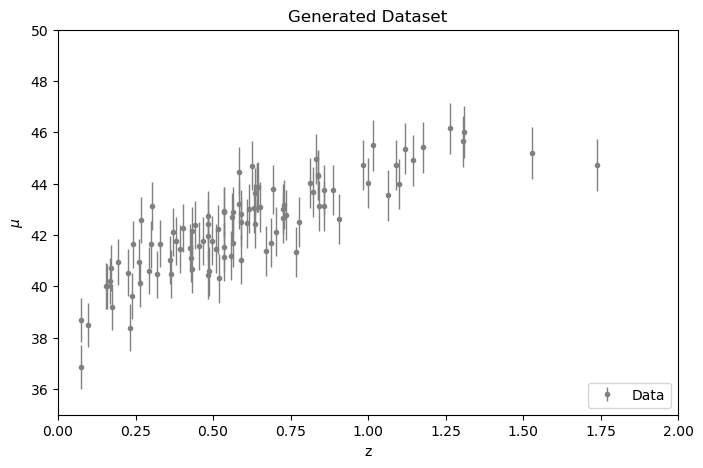

In [4]:
plt.figure(figsize=(8,5))
plt.errorbar(
    z_sample,
    mu_sample,
    dmu,
    fmt='.',
    color='gray',
    lw=1,
    label='Data'
)

plt.xlabel('z')
plt.ylabel('$\\mu$')
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)
plt.title('Generated Dataset')
plt.show()

In [5]:
X = z_sample.reshape(-1,1)
y = mu_sample

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Polynomial regression models

In [6]:
train_errors = []
val_errors = []
cv_scores = []

In [7]:
max_degree = 10

In [8]:
for degree in range(1, max_degree+1):
    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    train_mse = mean_squared_error(y_train, y_train_pred)
    val_mse = mean_squared_error(y_val, y_val_pred)

    train_errors.append(train_mse)
    val_errors.append(val_mse)

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring='neg_mean_squared_error'
    )

    cv_mse = -scores.mean()
    cv_scores.append(cv_mse)

    print(f"Degree {degree}")
    print(f"Train MSE: {train_mse:.4f}")
    print(f"Validation MSE: {val_mse:.4f}")
    print(f"CV MSE: {cv_mse:.4f}")
    print('-' * 40)

Degree 1
Train MSE: 1.0216
Validation MSE: 0.7796
CV MSE: 1.0020
----------------------------------------
Degree 2
Train MSE: 0.8034
Validation MSE: 0.9095
CV MSE: 0.8949
----------------------------------------
Degree 3
Train MSE: 0.8034
Validation MSE: 0.9091
CV MSE: 0.9443
----------------------------------------
Degree 4
Train MSE: 0.7526
Validation MSE: 0.8304
CV MSE: 1.1143
----------------------------------------
Degree 5
Train MSE: 0.7467
Validation MSE: 0.8025
CV MSE: 0.9659
----------------------------------------
Degree 6
Train MSE: 0.7439
Validation MSE: 0.7956
CV MSE: 4.5891
----------------------------------------
Degree 7
Train MSE: 0.7077
Validation MSE: 0.8440
CV MSE: 2.3409
----------------------------------------
Degree 8
Train MSE: 0.7077
Validation MSE: 0.8436
CV MSE: 1.8001
----------------------------------------
Degree 9
Train MSE: 0.7077
Validation MSE: 0.8462
CV MSE: 25.4836
----------------------------------------
Degree 10
Train MSE: 0.7006
Validation MSE: 0

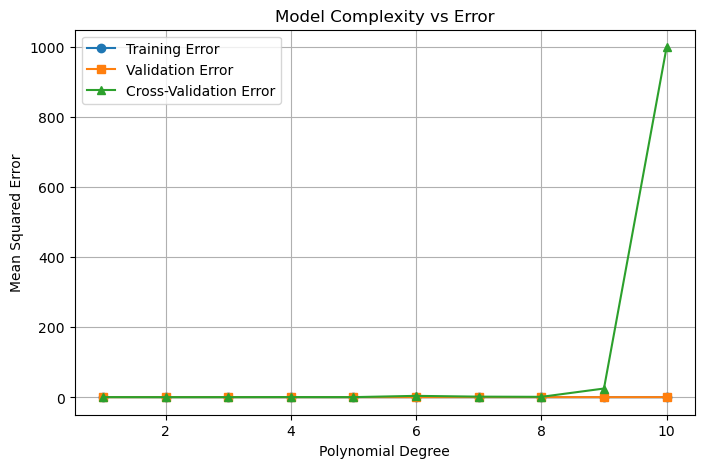

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, max_degree + 1), train_errors, 'o-', label='Training Error')
plt.plot(range(1, max_degree + 1), val_errors, 's-', label='Validation Error')
plt.plot(range(1, max_degree + 1), cv_scores, '^-', label='Cross-Validation Error')

plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error')
plt.title('Model Complexity vs Error')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
best_degree = np.argmin(cv_scores) + 1
print(f"Best polynomial degree from CV: {best_degree}")

Best polynomial degree from CV: 2


In [11]:
best_model = make_pipeline(
    PolynomialFeatures(best_degree),
    LinearRegression()
)

best_model.fit(X_train, y_train)

,steps,"[('polynomialfeatures', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,np.int64(2)
,interaction_only,False
,include_bias,True
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


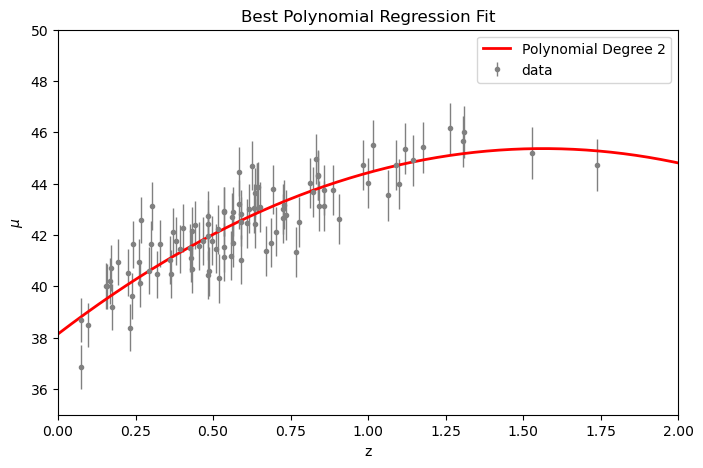

In [12]:
z_fit = np.linspace(0, 2, 500).reshape(-1, 1)
mu_fit = best_model.predict(z_fit)

plt.figure(figsize=(8, 5))

plt.errorbar(
    z_sample,
    mu_sample,
    dmu,
    fmt='.',
    color='gray',
    lw=1,
    label='data'
)

plt.plot(
    z_fit,
    mu_fit,
    color='red',
    lw=2,
    label=f'Polynomial Degree {best_degree}'
)

plt.xlabel('z')
plt.ylabel('$\\mu$')
plt.title('Best Polynomial Regression Fit')
plt.legend()
plt.xlim(0, 2)
plt.ylim(35, 50)
plt.show()

In [13]:
from sklearn.kernel_ridge import KernelRidge

In [14]:
kernel_model = KernelRidge(
    alpha=0.01,
    kernel='rbf',
    gamma=10
)

kernel_model.fit(X_train, y_train)

mu_kernel = kernel_model.predict(z_fit)

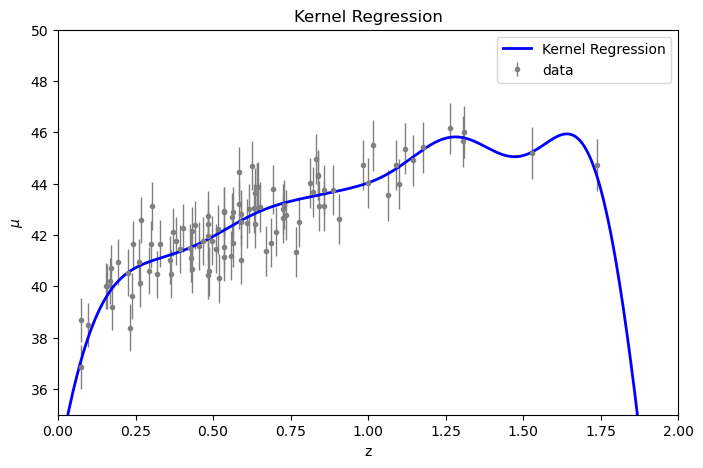

In [15]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    z_sample,
    mu_sample,
    dmu,
    fmt='.',
    color='gray',
    lw=1,
    label='data'
)

plt.plot(
    z_fit,
    mu_kernel,
    color='blue',
    lw=2,
    label='Kernel Regression'
)

plt.xlabel('z')
plt.ylabel('$\\mu$')
plt.title('Kernel Regression')
plt.legend()
plt.xlim(0, 2)
plt.ylim(35, 50)
plt.show()

 ### Part Two

In [17]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF,
    ConstantKernel,
    WhiteKernel
)

In [18]:
kernel = (
    ConstantKernel(1.0, (1e-3, 1e3))
    * RBF(length_scale=0.3, length_scale_bounds=(1e-2, 10))
    + WhiteKernel(noise_level=0.1)
)

In [19]:
gpr = GaussianProcessRegressor(
    kernel=kernel,
    alpha=dmu**2,
    n_restarts_optimizer=10,
    normalize_y=True,
    random_state=42
)

In [20]:
gpr.fit(X, y)

C:\Users\utente\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,kernel,1**2 * RBF(le...ise_level=0.1)
,alpha,"array([0.8438..., 0.92548723])"
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,10
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,42
,kernel__k1,1**2 * RBF(length_scale=0.3)
,kernel__k2,WhiteKernel(noise_level=0.1)
,kernel__k1__k1,1**2


In [21]:
z_fit = np.linspace(0, 2, 500)
X_fit = z_fit.reshape(-1, 1)

mu_pred, sigma = gpr.predict(
    X_fit,
    return_std=True
)

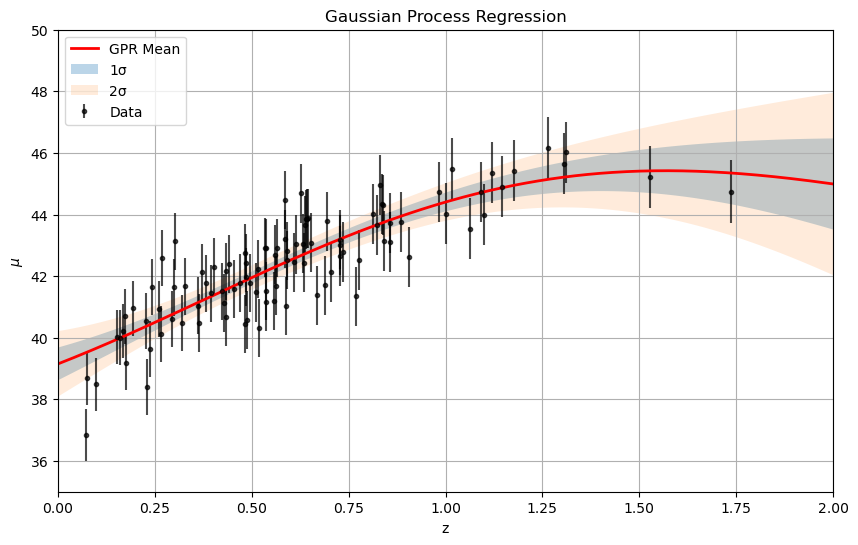

In [22]:
plt.figure(figsize=(10, 6))

# Data
plt.errorbar(
    z_sample,
    mu_sample,
    dmu,
    fmt='.',
    color='black',
    alpha=0.7,
    label='Data'
)

# Mean prediction
plt.plot(
    z_fit,
    mu_pred,
    color='red',
    lw=2,
    label='GPR Mean'
)

# 1-sigma contour
plt.fill_between(
    z_fit,
    mu_pred - sigma,
    mu_pred + sigma,
    alpha=0.3,
    label='1σ'
)

# 2-sigma contour
plt.fill_between(
    z_fit,
    mu_pred - 2*sigma,
    mu_pred + 2*sigma,
    alpha=0.15,
    label='2σ'
)

plt.xlabel('z')
plt.ylabel(r'$\mu$')
plt.title('Gaussian Process Regression')
plt.xlim(0, 2)
plt.ylim(35, 50)
plt.legend()
plt.grid(True)

plt.show()

In [23]:
print("Optimized Kernel:")
print(gpr.kernel_)

Optimized Kernel:
2.21**2 * RBF(length_scale=1.11) + WhiteKernel(noise_level=1e-05)


In [24]:
N_new = 1000

z_new = np.random.choice(
    z_sample,
    size=N_new,
    replace=True
)

z_new = np.sort(z_new)

X_new = z_new.reshape(-1, 1)

In [25]:
mu_new_mean, mu_new_sigma = gpr.predict(
    X_new,
    return_std=True
)

In [26]:
mu_new = np.random.normal(
    mu_new_mean,
    mu_new_sigma
)

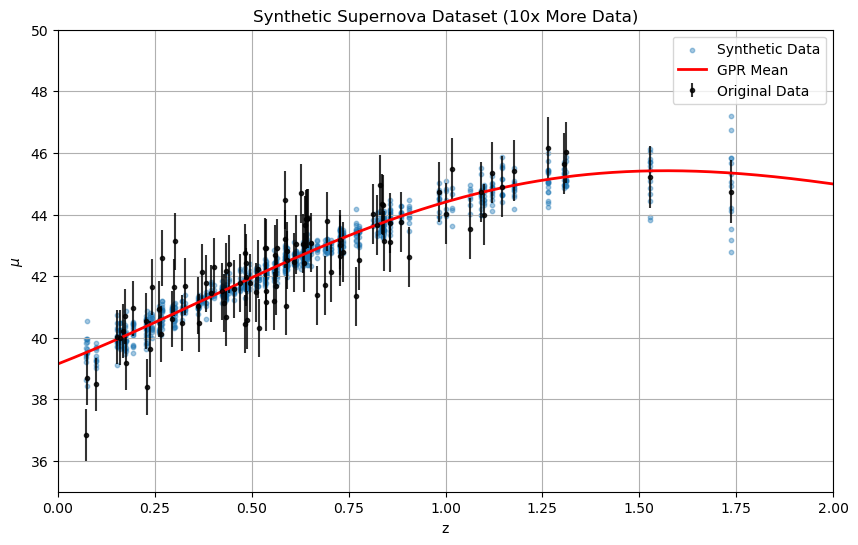

In [27]:
plt.figure(figsize=(10, 6))

# Original data
plt.errorbar(
    z_sample,
    mu_sample,
    dmu,
    fmt='.',
    color='black',
    alpha=0.8,
    label='Original Data'
)

# New synthetic data
plt.scatter(
    z_new,
    mu_new,
    s=10,
    alpha=0.4,
    label='Synthetic Data'
)

# GPR fit
plt.plot(
    z_fit,
    mu_pred,
    color='red',
    lw=2,
    label='GPR Mean'
)

plt.xlabel('z')
plt.ylabel(r'$\mu$')
plt.title('Synthetic Supernova Dataset (10x More Data)')
plt.xlim(0, 2)
plt.ylim(35, 50)
plt.legend()
plt.grid(True)

plt.show()

In [28]:
print("\nINTERPRETATION")
print("- The red curve is the expected value from the GPR.")
print("- The shaded regions represent uncertainty bands.")
print("- 1σ contains about 68% probability.")
print("- 2σ contains about 95% probability.")
print("- The synthetic dataset follows the statistical")
print("  properties learned from the original data.")


INTERPRETATION
- The red curve is the expected value from the GPR.
- The shaded regions represent uncertainty bands.
- 1σ contains about 68% probability.
- 2σ contains about 95% probability.
- The synthetic dataset follows the statistical
  properties learned from the original data.


### Part Three

In [48]:
from scipy.integrate import quad
import emcee
import corner

In [49]:
c = 299792.458

In [50]:
def E(z, Omega_m):

    Omega_lambda = 1.0 - Omega_m

    return np.sqrt(
        Omega_m * (1 + z)**3
        + Omega_lambda
    )

In [51]:
def integral_distance(z, Omega_m):

    integral, _ = quad(
        lambda zp: 1.0 / E(zp, Omega_m),
        0,
        z
    )

    return integral

In [52]:
def mu_model(z, H0, Omega_m):

    mu = np.zeros_like(z)

    for i, zi in enumerate(z):
        integral = integral_distance(
            zi,
            Omega_m
        )

        DL_Mpc = (
            (c / H0)
            * (1 + zi)
            * integral
        )

        DL_pc = DL_Mpc * 1e6

        mu[i] = 5 * np.log10(
            DL_pc / 10
        )

    return mu

In [53]:
def log_likelihood(theta, z, mu_obs, dmu):

    H0, Omega_m = theta

    mu_th = mu_model(
        z,
        H0,
        Omega_m
    )

    chi2 = np.sum(
        ((mu_obs - mu_th) / dmu)**2
    )

    return -0.5 * chi2

In [54]:
def log_prior(theta):

    H0, Omega_m = theta

    if 50 < H0 < 100 and 0 < Omega_m < 1:
        return 0.0

    return -np.inf

In [55]:
def log_probability(theta, z, mu_obs, dmu):

    lp = log_prior(theta)

    if not np.isfinite(lp):
        return -np.inf

    return lp + log_likelihood(
        theta,
        z,
        mu_obs,
        dmu
    )

In [56]:
ndim = 2
nwalkers = 32

In [57]:
initial = np.array([
    70,
    0.3
])

In [58]:
pos = initial + 1e-2 * np.random.randn(
    nwalkers,
    ndim
)

In [59]:
sampler = emcee.EnsembleSampler(
    nwalkers,
    ndim,
    log_probability,
    args=(
        z_sample,
        mu_sample,
        dmu
    )
)

In [60]:
print("Running MCMC...")

sampler.run_mcmc(
    pos,
    3000,
    progress=True
)

Running MCMC...


100%|██████████████████████████████████████████████████████████████████████████████| 3000/3000 [15:23<00:00,  3.25it/s]


State([[6.41490829e+01 5.37402524e-01]
 [7.24600451e+01 3.74581867e-01]
 [8.22383862e+01 4.32381319e-02]
 [6.77709081e+01 1.80849599e-01]
 [6.59134323e+01 4.17637053e-01]
 [6.68511130e+01 2.81752017e-01]
 [6.66774620e+01 4.80297942e-01]
 [7.56058048e+01 4.91379717e-02]
 [5.97644116e+01 5.10720047e-01]
 [7.74740500e+01 5.16788301e-02]
 [5.65152092e+01 6.43307958e-01]
 [6.76927230e+01 4.21487518e-01]
 [6.86096397e+01 3.78224551e-01]
 [5.69616638e+01 9.47669015e-01]
 [6.47929914e+01 6.60963432e-01]
 [7.11751877e+01 3.27840751e-01]
 [6.91812990e+01 1.39335583e-01]
 [7.00502546e+01 3.31889482e-01]
 [7.55488318e+01 3.22206729e-02]
 [6.44836163e+01 4.00896425e-01]
 [5.65484375e+01 8.79491103e-01]
 [6.53871600e+01 6.83805450e-01]
 [7.81427812e+01 1.40550203e-01]
 [5.96750473e+01 7.96022679e-01]
 [5.95255648e+01 7.58051805e-01]
 [5.67460636e+01 9.77350216e-01]
 [7.25060325e+01 1.86161073e-01]
 [6.88882582e+01 2.27897682e-01]
 [6.11797235e+01 9.00675746e-01]
 [6.26923114e+01 5.54518811e-01]
 [6.

In [61]:
samples = sampler.get_chain(
    discard=500,
    thin=10,
    flat=True
)

In [62]:
H0_mcmc = np.percentile(
    samples[:, 0],
    [16, 50, 84]
)

Omega_m_mcmc = np.percentile(
    samples[:, 1],
    [16, 50, 84]
)


In [63]:
H0_med = H0_mcmc[1]
H0_minus = H0_mcmc[1] - H0_mcmc[0]
H0_plus = H0_mcmc[2] - H0_mcmc[1]

Omega_med = Omega_m_mcmc[1]
Omega_minus = Omega_m_mcmc[1] - Omega_m_mcmc[0]
Omega_plus = Omega_m_mcmc[2] - Omega_m_mcmc[1]

In [64]:
print("\n===== MCMC RESULTS =====")

print(
    f"H0 = {H0_med:.2f}"
    f" +{H0_plus:.2f}"
    f" -{H0_minus:.2f}"
)

print(
    f"Omega_m = {Omega_med:.3f}"
    f" +{Omega_plus:.3f}"
    f" -{Omega_minus:.3f}"
)


===== MCMC RESULTS =====
H0 = 66.71 +7.15 -6.21
Omega_m = 0.435 +0.332 -0.256


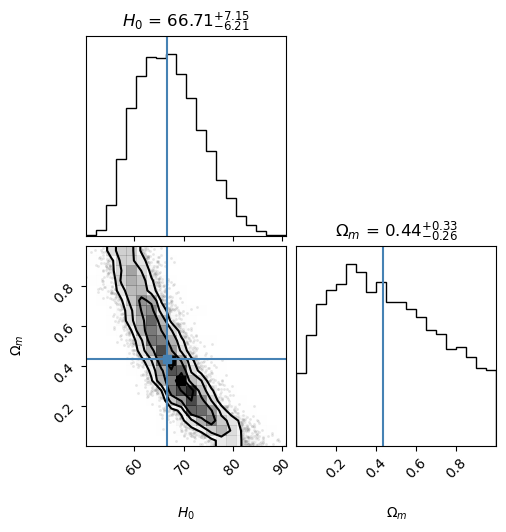

In [65]:
figure = corner.corner(
    samples,
    labels=[
        r"$H_0$",
        r"$\Omega_m$"
    ],
    truths=[
        H0_med,
        Omega_med
    ],
    show_titles=True
)

plt.show()


In [66]:
z_fit = np.linspace(
    0.001,
    2.0,
    500
)

mu_fit = mu_model(
    z_fit,
    H0_med,
    Omega_med
)


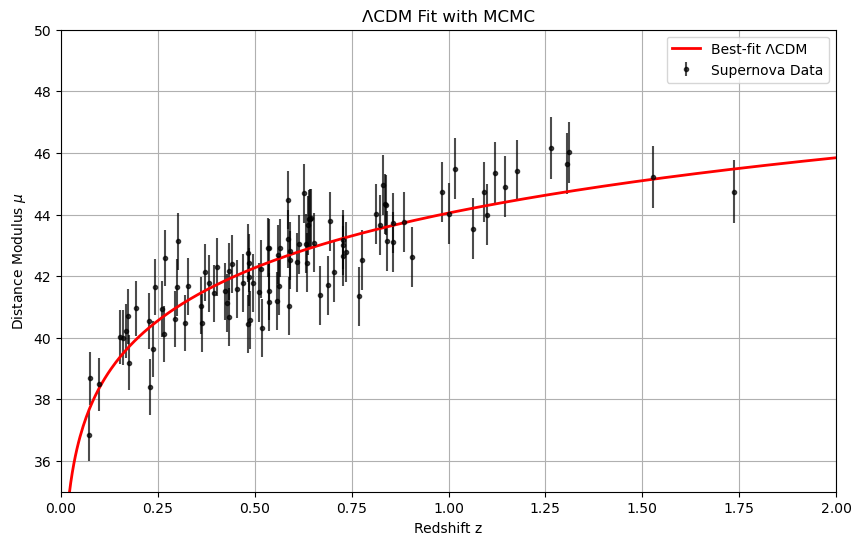

In [67]:
plt.figure(figsize=(10, 6))

# Data
plt.errorbar(
    z_sample,
    mu_sample,
    dmu,
    fmt='.',
    color='black',
    alpha=0.7,
    label='Supernova Data'
)

# MCMC best-fit model
plt.plot(
    z_fit,
    mu_fit,
    color='red',
    lw=2,
    label='Best-fit ΛCDM'
)

plt.xlabel('Redshift z')
plt.ylabel(r'Distance Modulus $\mu$')

plt.title('ΛCDM Fit with MCMC')

plt.xlim(0, 2)
plt.ylim(35, 50)

plt.legend()
plt.grid(True)

plt.show()

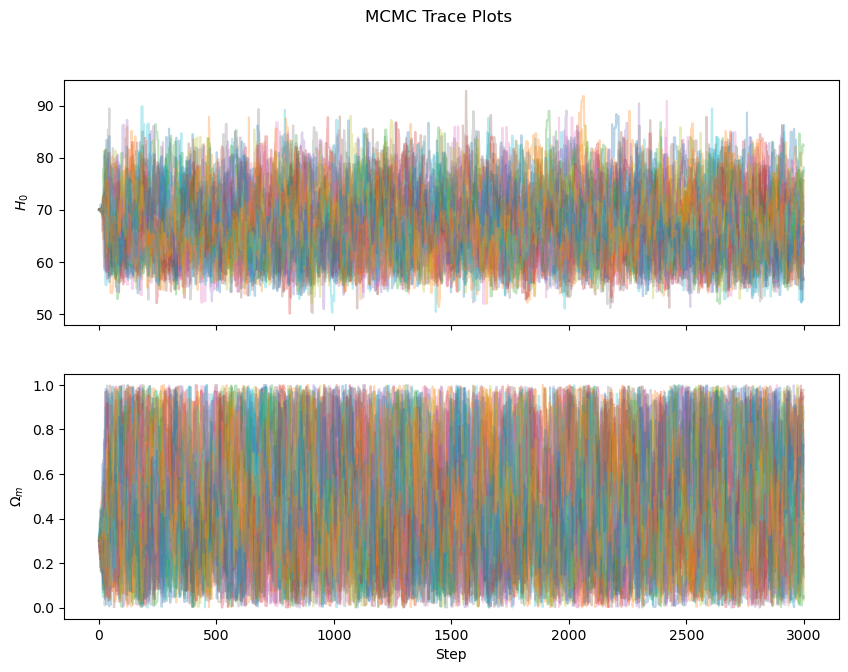

In [68]:
chains = sampler.get_chain()

fig, axes = plt.subplots(
    2,
    figsize=(10, 7),
    sharex=True
)

labels = [r"$H_0$", r"$\Omega_m$"]

for i in range(ndim):

    ax = axes[i]

    ax.plot(
        chains[:, :, i],
        alpha=0.3
    )

    ax.set_ylabel(labels[i])

axes[-1].set_xlabel("Step")

plt.suptitle("MCMC Trace Plots")

plt.show()

In [69]:
mu_best = mu_model(
    z_sample,
    H0_med,
    Omega_med
)

chi2 = np.sum(
    ((mu_sample - mu_best) / dmu)**2
)

ndof = len(mu_sample) - ndim

reduced_chi2 = chi2 / ndof

print("\n===== GOODNESS OF FIT =====")

print(f"Chi2 = {chi2:.2f}")

print(f"Reduced Chi2 = {reduced_chi2:.2f}")


===== GOODNESS OF FIT =====
Chi2 = 92.83
Reduced Chi2 = 0.95


In [70]:
print("\n===== INTERPRETATION =====")

print("- The corner plot shows posterior distributions.")

print("- Elliptical contours indicate correlations")
print("  between H0 and Ωm.")

print("- Trace plots help verify MCMC convergence.")

print("- Reduced χ² close to 1 indicates")
print("  a statistically good fit.")

print("- Wider posteriors indicate weaker constraints.")

print("- The Bayesian approach gives the full")
print("  posterior probability distribution,")
print("  not just a single best-fit value.")


===== INTERPRETATION =====
- The corner plot shows posterior distributions.
- Elliptical contours indicate correlations
  between H0 and Ωm.
- Trace plots help verify MCMC convergence.
- Reduced χ² close to 1 indicates
  a statistically good fit.
- Wider posteriors indicate weaker constraints.
- The Bayesian approach gives the full
  posterior probability distribution,
  not just a single best-fit value.
